In [1]:
import os
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

from langgraph.prebuilt import create_react_agent

from IPython.display import Image, display

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

##### Load PDF

In [4]:
loader = PyPDFLoader("docs/Autonomous Data Science Agent.pdf")
docs = loader.load()

##### Split Documents

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_documents(docs)

print(len(chunks))

133


##### Embeddings

In [6]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

d:\RAG\rag_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5412.48it/s]


##### Vector Store

In [7]:
vectorstore = FAISS.from_documents(
    chunks,
    embeddings
)

##### Retriever

In [8]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k":4}
)

#### Rag Tool

In [9]:
@tool
def retrieve_documents(query: str) -> str:
    """
    Search information from PDF knowledge base.
    """

    docs = retriever.invoke(query)

    if not docs:
        return "No relevant information found."

    return "\n\n".join(
        [doc.page_content for doc in docs]
    )

##### Web Search

In [10]:
search = DuckDuckGoSearchRun()

@tool
def web_search(query: str) -> str:
    """
    Search latest information from the internet.
    """

    return search.run(query)

##### Calculator Tool

In [11]:
@tool
def calculator(expression: str) -> str:
    """
    Useful for mathematical calculations.
    """

    try:
        return str(eval(expression))
    except Exception as e:
        return str(e)

##### Register Tools

In [12]:
tools = [
    retrieve_documents,
    web_search,
    calculator
]

##### Create ReAct Agent

In [13]:
agent = create_react_agent(
    llm,
    tools
)

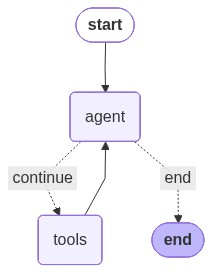

In [14]:
display(
    Image(
        agent.get_graph().draw_mermaid_png()
    )
)

In [15]:
while True:

    query = input("Ask: ")

    if query.lower() == "exit":
        break

    result = agent.invoke(
        {
            "messages":[
                (
                    "human",
                    query
                )
            ]
        }
    )

    print("User:", query)
    print("\nAssistant:")
    print(result["messages"][-1].content)

d:\RAG\rag_venv\lib\site-packages\langchain_community\utilities\duckduckgo_search.py:61: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
d:\RAG\rag_venv\lib\site-packages\langchain_community\utilities\duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(
d:\RAG\rag_venv\lib\site-packages\langchain_groq\chat_models.py:665: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  response = response.dict()
d:\RAG\rag_venv\lib\site-packages\langchain_community\utilities\duckduckgo_search.py:61: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
d:\RAG\rag_venv\lib\site-packages\langchain_community\utilities\

User: EvoDS Skill Learning and Context Management

Assistant:
## EvoDS – Skill Learning & Context Management  
*(Evolutionary‑Driven Development System)*  

EvoDS is a **modular, evolutionary‑based framework** for building autonomous agents that can **discover, acquire, and reuse skills** while **maintaining a rich, hierarchical context** of what they are doing, why they are doing it, and how the environment is changing.  

Below is a **complete guide** that covers the theory, architecture, implementation steps, best‑practice patterns, and concrete examples you can start using today.

---

## 1. Core Concepts  

| Concept | What it means in EvoDS | Why it matters |
|---------|-----------------------|----------------|
| **Skill** | A reusable policy or procedure that maps a *state* (or a set of contextual cues) to an *action sequence* that achieves a sub‑goal. Skills can be **primitive** (e.g., “move forward 1 m”) or **composite** (e.g., “navigate to a door”). | Encapsulates knowledge, 

d:\RAG\rag_venv\lib\site-packages\langchain_groq\chat_models.py:665: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  response = response.dict()


User: what is Transformern in Deep learning ?

Assistant:
**Transformer** (often mistakenly written as “Transformern”) is a neural‑network architecture that has become the dominant building block for modern deep‑learning models, especially in natural‑language processing (NLP) but also in vision, speech, reinforcement learning, and many other domains.

Below is a concise yet thorough overview that covers **what a Transformer is**, **how it works**, **why it matters**, and **where it’s used today**.

---

## 1. Core Idea

The Transformer replaces the recurrent or convolutional structures that were traditionally used to process sequences (e.g., RNNs, LSTMs, CNNs) with **self‑attention** mechanisms.  
Self‑attention lets every element of a sequence directly attend to (i.e., weigh) every other element, enabling:

| Benefit | Explanation |
|---------|--------------|
| **Parallelism** | All positions are processed simultaneously (no sequential dependence). |
| **Long‑range dependencies** | Ea

d:\RAG\rag_venv\lib\site-packages\langchain_groq\chat_models.py:665: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  response = response.dict()
